In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from concept_abstraction.plotting import *
from concept_abstraction.utils import *
import matplotlib.lines as mlines

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [4]:
style_size = 'paper'

## New Plots

In [5]:
training_times = {
    'cart_pole': 4_000_000,
    'mini_grid': 500_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 15_000_000,
}

gold_timesteps = {
    'cart_pole': 4_000_000,
    'mini_grid': 1_000_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 30_000_000,
}

name_to_nice = {
    'cart_pole': "CartPole",
    'mini_grid': "MiniGrid",
    'glucose': 'Glucose',
    'pong': "Pong",
    'boxing': "Boxing"
}

methods_to_nice = {
    'random': 'Random',
    'entropy': 'Variance',
    'greedy': 'Greedy',
    'lp_hybrid': "CSA",
    'multiple_log': 'CSA-Log'
}

methods_dict = {
    0: 'Random',
    1: 'Variance',
    2: 'Greedy',
    3: 'CSA',
    4: 'CSA-Log'   
}

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

method_scales = [lambda d: d/500*100, lambda d: d/1*100, lambda d: (d+21)/42*100, lambda d: d/100*100, lambda d: (d+20)/(40+20)*100]

In [107]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["perfect_concepts","random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["imperfect_concepts","random","entropy","greedy","lp_hybrid","multiple_log"]

all_performances_perfect = []
all_performances_perfect_std = []

all_performances_imperfect = []
all_performances_imperfect_std = []

all_baselines = []

for j,e in enumerate(perfect_environments):
    temp = []
    temp_std = []
    for m in perfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Perfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])

        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

        performance = method_scales[j](np.std([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))/len(matching_params)**.5
        temp_std.append(performance)
    all_performances_perfect.append(temp)
    all_performances_perfect_std.append(temp_std)

for j,e in enumerate(imperfect_environments):
    temp = []
    temp_std = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])
        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

        performance = method_scales[j](np.std([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))/len(matching_params)**.5
        temp_std.append(performance)

        if m == 'multiple_log':
            print("Environment",e,[i['concept_accuracy'] for i in matching_params])

    all_performances_imperfect.append(temp)
    all_performances_imperfect_std.append(temp_std)

for j,e in enumerate(imperfect_environments):
    matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],'gold_timesteps': gold_timesteps[e],
                                                                'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison', 'method': 'ground_truth'})
    m = 'ground_truth'
    print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed']) for i in matching_params if m in i])
    performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
    all_baselines.append(performance)
all_baselines.append(0)

Perfect cart_pole perfect_concepts 3 [(499.5, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.875, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.915, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])]
Perfect cart_pole random 3 [(173.9106830122592, 44, [0, 9, 10]), (171.32413793103447, 42, [0, 9, 10]), (172.8411867364747, 43, [0, 9, 10])]
Perfect cart_pole entropy 3 [(104.6621052631579, 44, [3, 0, 9]), (105.5270413573701, 42, [3, 0, 9]), (106.8741935483871, 43, [3, 0, 9])]
Perfect cart_pole greedy 3 [(164.65671641791045, 44, [9, 10, 11]), (163.0935960591133, 43, [9, 10, 11]), (167.53807106598984, 42, [9, 10, 11])]
Perfect cart_pole lp_hybrid 3 [(204.00821355236138, 42, [1, 4, 7]), (413.1386554621849, 44, [1, 7, 10]), (381.36293436293437, 43, [0, 6, 10])]
Perfect mini_grid perfect_concepts 3 [(0.9595455418019246, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]), (0.

Perfect boxing greedy 3 [(79.8, 43, [107, 137, 117, 147, 157, 167, 127, 177, 187, 77, 17, 27, 97, 37, 57, 67, 87, 47, 7, 189, 179, 169, 129, 159, 149, 119, 109, 139, 89, 9, 29, 79, 69, 99, 59, 39, 19, 49, 111, 14, 44, 94, 64, 74, 84, 4, 54, 34]), (85.2279792746114, 42, [27, 37, 67, 77, 87, 7, 17, 47, 57, 97, 19, 39, 49, 29, 9, 99, 89, 59, 79, 69, 109, 149, 169, 129, 179, 139, 189, 119, 159, 186, 146, 106, 136, 116, 166, 156, 126, 176, 55, 95, 15, 45, 25, 35, 75, 85, 5, 65]), (91.61685823754789, 44, [131, 146, 156, 126, 116, 166, 136, 176, 106, 186, 76, 86, 96, 6, 46, 16, 66, 36, 26, 56, 133, 4, 64, 14, 24, 94, 34, 44, 54, 84, 74, 167, 117, 157, 127, 177, 147, 187, 137, 107, 155, 175, 105, 115, 165, 135, 185, 125])]
Perfect boxing lp_hybrid 3 [(86.36440677966101, 44, [7, 16, 17, 26, 27, 36, 37, 44, 45, 46, 47, 57, 66, 67, 77, 87, 96, 97, 99, 105, 107, 109, 110, 111, 115, 119, 121, 122, 123, 125, 129, 131, 132, 133, 135, 139, 145, 149, 155, 159, 165, 169, 175, 179, 184, 185, 186, 189]), 

4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1


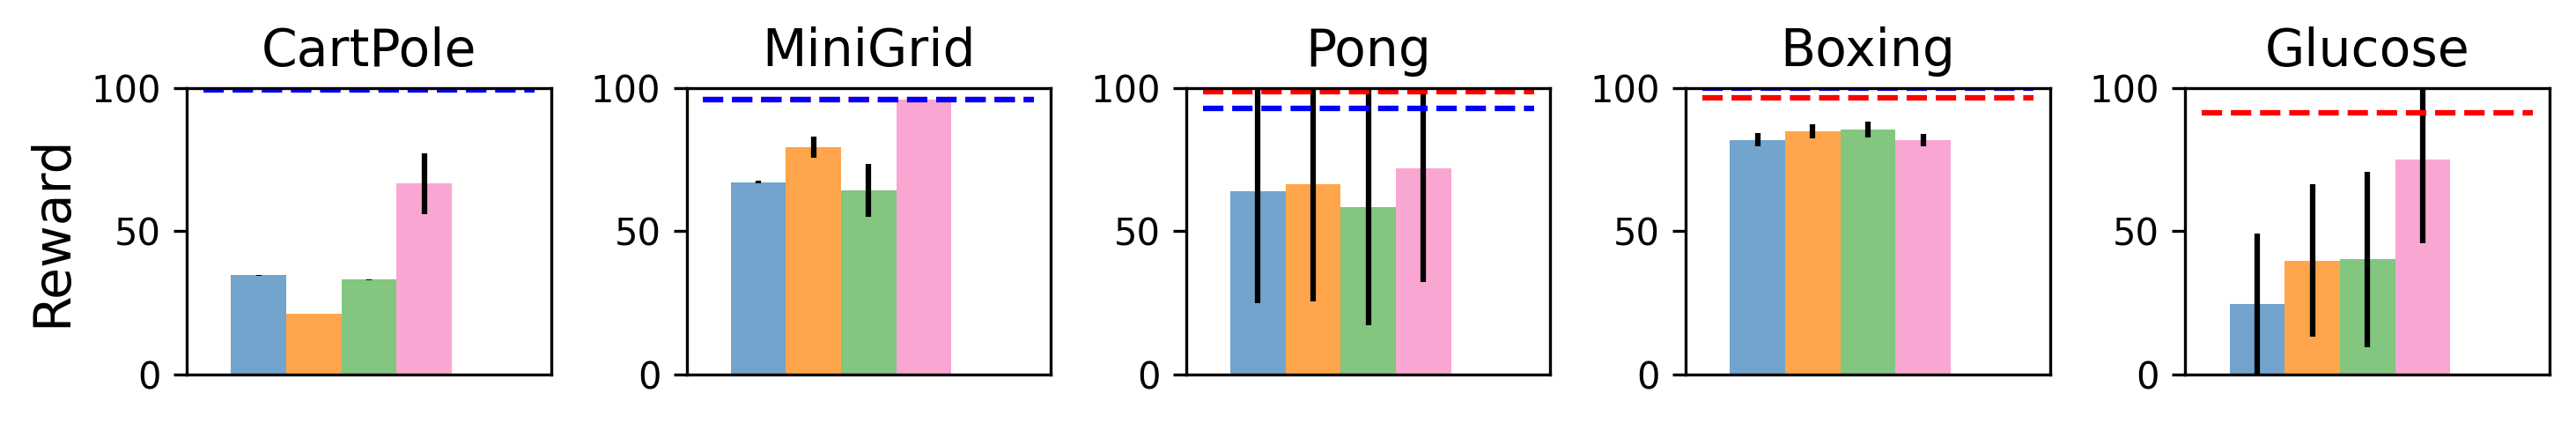

In [108]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]
y_labels = [["" for i in range(len(perfect_environments))]]
y_labels[0][0] = "Reward"

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(5)]],
    'x_ticks': [[[[],[]] for i in range(5)]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,y_labels=y_labels)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(perfect_environments)):
    x_groups = list(range(len(all_performances_perfect[i][:-1])))
    y_vals = all_performances_perfect[i][1:]
    y_std = all_performances_perfect_std[i][1:]


    plot_bar(ax[0][i],x_groups,y_vals,y_std, methods_dict,bar_format)
    
    ax[0][i].hlines(all_performances_perfect[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    
    if i!=len(perfect_environments)-1:
        ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

# legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.1,-0.1),'fontsize': 14}
# create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_perfect.pdf",dpi=300, bbox_inches='tight')

5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1


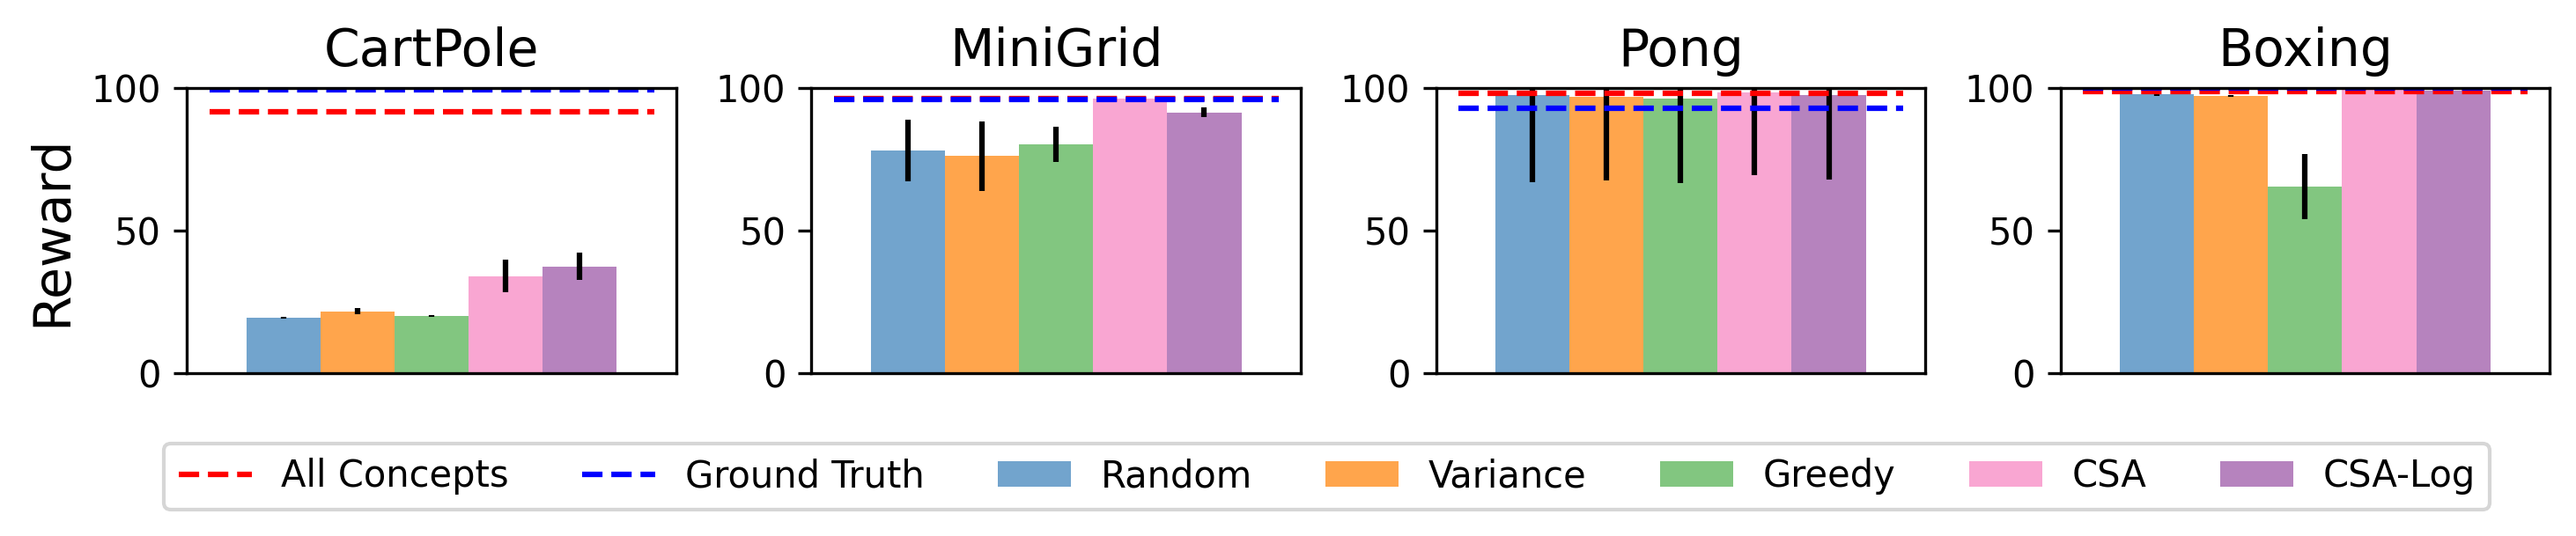

In [109]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]
y_labels = [["" for i in range(len(imperfect_environments))]]
y_labels[0][0] = "Reward"

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(4)]],
    'x_ticks': [[[[],[]] for i in range(5)]]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,y_labels=y_labels)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect[i][:-1])))
    y_vals = all_performances_imperfect[i][1:]
    y_std = all_performances_imperfect_std[i][1:]

    plot_bar(ax[0][i],x_groups,y_vals,y_std, methods_dict,bar_format)
    
    ax[0][i].hlines(all_performances_imperfect[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 7, 'bbox_to_anchor': (0.075
                                                                                                                ,-0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_imperfect.pdf",dpi=300, bbox_inches='tight')

In [23]:
all_performances_perfect[-1][-1]/all_performances_perfect[-1][-2]

1.8729253144991633

In [24]:
all_performances_perfect[0][-1]/all_performances_perfect[0][1]

1.9273422983808137

In [27]:
all_performances_perfect[-2][-2]/all_performances_perfect[-2][-1]

1.0446842532428102

In [35]:
all_performances_imperfect[0][-2]/all_performances_imperfect[0][2]

1.5643606881257857

In [37]:
all_performances_imperfect[1][-2]/np.max(all_performances_imperfect[1][1:-2])

1.2018973982061827

In [38]:
all_performances_imperfect[0][-1]/all_performances_imperfect[0][-2]

1.0985655335660707

In [44]:
for j,e in enumerate(imperfect_environments):
    temp = []
    temp_std = []
    ours = []

    for m in ['lp_hybrid','multiple_log']:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        ours.append([i[m]['concepts'] for i in matching_params])
    
    avg = []
    for i in ours[0]:
        for j in ours[1]:
            avg.append(len(set(i).intersection(set(j)))/len(j))
    print(np.mean(avg))

0.2962962962962963
0.4083694083694083
0.0682261208576998
0.048611111111111105


In [104]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid","multiple_log"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_k = []
all_performances_k_std = []

for j,e in enumerate(perfect_environments):
    temp_env = []
    temp_env_std = []

    for m in perfect_methods:
        temp = []
        temp_std = []

        for fraction_selected in [0.33,0.66,1]:
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                        'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                        'method': m, 'gold_timesteps': gold_timesteps[e],'experiment': 'perfect_comparison'})


            if len(matching_params) == 0:
                matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                            'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                            'method': m, 'gold_timesteps': gold_timesteps[e], 'experiment': 'perfect_comparison'})

            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
            print("Perfect",e,m,round(num_concepts_selected[e]*fraction_selected),[i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])],np.mean( [len(matching_params[i][m]['concepts']) for i in range(len(matching_params))]))

            if np.isnan(performance):
                performance = 0
            temp.append(performance)

            performance_std = method_scales[j](np.std([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))/len(matching_params)**.5
            temp_std.append(performance_std)

        temp_env.append(temp)
        temp_env_std.append(temp_std)
    all_performances_k.append(temp_env)
    all_performances_k_std.append(temp_env_std)


Perfect cart_pole random 1 [112.26727066817666, 112.20744081172492, 112.21468926553672] 1.0
Perfect cart_pole random 2 [164.70364238410596, 164.03471074380164, 165.74376039933443] 2.0
Perfect cart_pole random 3 [173.9106830122592, 171.32413793103447, 172.8411867364747] 3.0
Perfect cart_pole entropy 1 [39.99559647718174, 40.17538213998391, 112.26727066817666] 1.0
Perfect cart_pole entropy 2 [110.55937846836848, 113.44697833523375, 41.23347107438016] 2.0
Perfect cart_pole entropy 3 [104.6621052631579, 105.5270413573701, 106.8741935483871] 3.0
Perfect cart_pole greedy 1 [112.21468926553672, 29.549141503848432, 112.26727066817666] 1.0
Perfect cart_pole greedy 2 [98.65609514370664, 112.54761904761905, 161.92659053833606] 2.0
Perfect cart_pole greedy 3 [164.65671641791045, 163.0935960591133, 167.53807106598984] 3.0
Perfect cart_pole lp_hybrid 1 [112.26727066817666, 112.20744081172492, 112.21468926553672] 1.0
Perfect cart_pole lp_hybrid 2 [328.1262458471761, 391.234126984127, 382.046511627906

[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[22.445960049695888, 32.965474235149465, 34.538400511984555], [12.829216619022818, 17.682655191865493, 21.137556011261005], [16.935406762504122, 24.875353648644115, 33.019225569534235], [22.445960049695888, 73.427125630614, 66.56732022516539]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[29.24421855200488, 41.17805743283458, 67.15678932106212], [16.53988316077532, 33.07323773038895, 79.33875041232935], [39.22079885880403, 45.94463828507055, 64.1841245020065], [36.114600810313256, 90.18613294363543, 96.01826604120718]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[7.0960679414517, 77.72657450076805, 63.87966763003531], [12.63577788839113, 29.183201058201057, 66.30168681892819], [15.135582010582013, 41.2799056820796, 58.51776618966772], [11.187484658185342, 50.11582915994681, 71.98273360971774]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[90.3240332930351, 75.65561456099776, 81.94008116237218], [77.60141267749964, 85.84661807161099, 84.

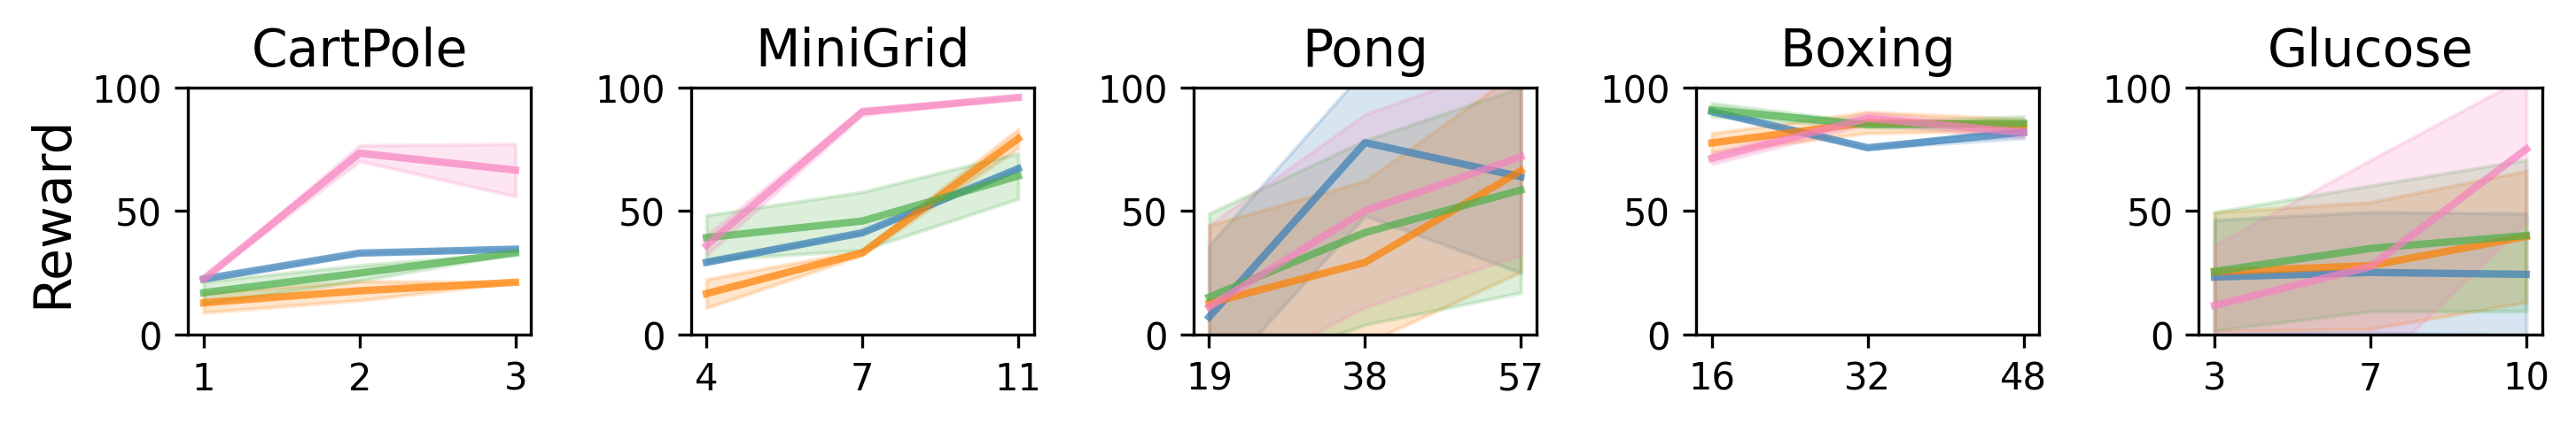

In [105]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]
y_labels = [["" for i in range(5)]]
y_labels[0][0] = "Reward"

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100],[0,100],[0,100],[0,100],[0,100]]],
    'x_ticks': [[[[0,1,2],[round(num_concepts_selected[perfect_environments[i]]*[0.33,0.66,1][j]) for j in range(3)]] for i in range(5)] for j in range(1)],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,y_labels=y_labels)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

for i in range(len(perfect_environments)):
    y_vals = all_performances_k[i]

    x_groups = [list(range(len(j))) for j in y_vals]

    print(x_groups,y_vals)

    plot_line(ax[0][i],x_groups,y_vals,all_performances_k_std[i], perfect_methods,line_format)
    
fig.savefig("../../results/figures/perfect_varied_k.pdf",dpi=300, bbox_inches='tight')

In [95]:
all_performances_k[-1][2][1]/all_performances_k[-1][3][1]

1.2679669328647893

In [103]:
all_performances_k[-1][3][2]/all_performances_k[-1][2][2]

1.8729253144991633

In [58]:
np.mean(np.array(all_performances_k)[0][-1])/np.mean(np.array(all_performances_k)[0][-4])

1.8058999916162173

In [106]:
np.mean(np.array(all_performances_k)[1][-1])/np.mean(np.array(all_performances_k)[1][-4])

1.615936256732363

In [65]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid","multiple_log"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_k = []
all_performances_k_std = []
for j,e in enumerate(imperfect_environments):
    temp_env = []
    temp_env_std = []
    for m in imperfect_methods:
        temp = []
        temp_std = []

        for fraction_selected in [0.33,0.66,1]:
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                        'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                        'method': m, 'gold_timesteps': gold_timesteps[e],'experiment': 'imperfect_comparison'})


            if len(matching_params) == 0:
                matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                            'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                            'method': m, 'gold_timesteps': gold_timesteps[e], 'experiment': 'imperfect_comparison'})

            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
            print("Perfect",e,m,round(num_concepts_selected[e]*fraction_selected),[i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])],np.mean( [len(matching_params[i][m]['concepts']) for i in range(len(matching_params))]))

            if np.isnan(performance):
                performance = 0
            temp.append(performance)

            performance = method_scales[j](np.std([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))/len(matching_params)**.5
            temp_std.append(performance)

        temp_env.append(temp)
        temp_env_std.append(temp_std)
    all_performances_k.append(temp_env)
    all_performances_k_std.append(temp_env_std)


Perfect cart_pole random 1 [75.43149129447389, 81.05126118795769, 88.20726306465899] 1.0
Perfect cart_pole random 2 [89.7954954954955, 75.75930144267274, 83.8357203032856] 2.0
Perfect cart_pole random 3 [98.75992063492063, 93.12418300653594, 99.547] 3.0
Perfect cart_pole entropy 1 [75.43149129447389, 31.459553037456722, 33.078476821192055] 1.0
Perfect cart_pole entropy 2 [52.17425431711146, 92.26851851851852, 101.55816326530612] 2.0
Perfect cart_pole entropy 3 [101.40570846075433, 122.1116564417178, 103.90615224191866] 3.0
Perfect cart_pole greedy 1 [75.43149129447389, 81.05126118795769, 32.04201411161001] 1.0
Perfect cart_pole greedy 2 [75.33711262282691, 90.6287534121929, 82.6298755186722] 2.0
Perfect cart_pole greedy 3 [102.66323377960865, 98.20808678500987, 101.67755102040816] 3.0
Perfect cart_pole lp_hybrid 1 [75.43149129447389, 81.05126118795769, 88.20726306465899] 1.0
Perfect cart_pole lp_hybrid 2 [128.05791505791507, 89.44753363228699, 90.14751131221719] 2.0
Perfect cart_pole l

Perfect cart_pole multiple_log 1 [88.20726306465899, 81.05126118795769, 75.43149129447389] 1.0
Perfect cart_pole multiple_log 2 [128.05791505791507, 95.3933014354067, 90.14751131221719] 2.0
Perfect cart_pole multiple_log 3 [143.7485549132948, 174.657848324515, 244.28817733990147] 3.0
Perfect mini_grid random 4 [0.5617956751330684, 0.5813949775444046, 0.5357078092749833] 4.0
Perfect mini_grid random 7 [0.6097324836659077, 0.7928686167572465, 0.7680314586204869] 7.0
Perfect mini_grid random 11 [0.9467911340657862, 0.8732119697710158, 0.5227517520503929] 11.0
Perfect mini_grid entropy 4 [0.10949589026300874, 0.21129938922139632, 0.3517074024692665] 4.0
Perfect mini_grid entropy 7 [0.35698338969304316, 0.2987028993126275, 0.4154875777800631] 7.0
Perfect mini_grid entropy 11 [0.4630556898025492, 0.9072940960599417, 0.9146312992210894] 11.0
Perfect mini_grid greedy 4 [0.6909504276373957, 0.3340896677141014, 0.24955384678278977] 4.0
Perfect mini_grid greedy 7 [0.7617230767616384, 0.4214498487

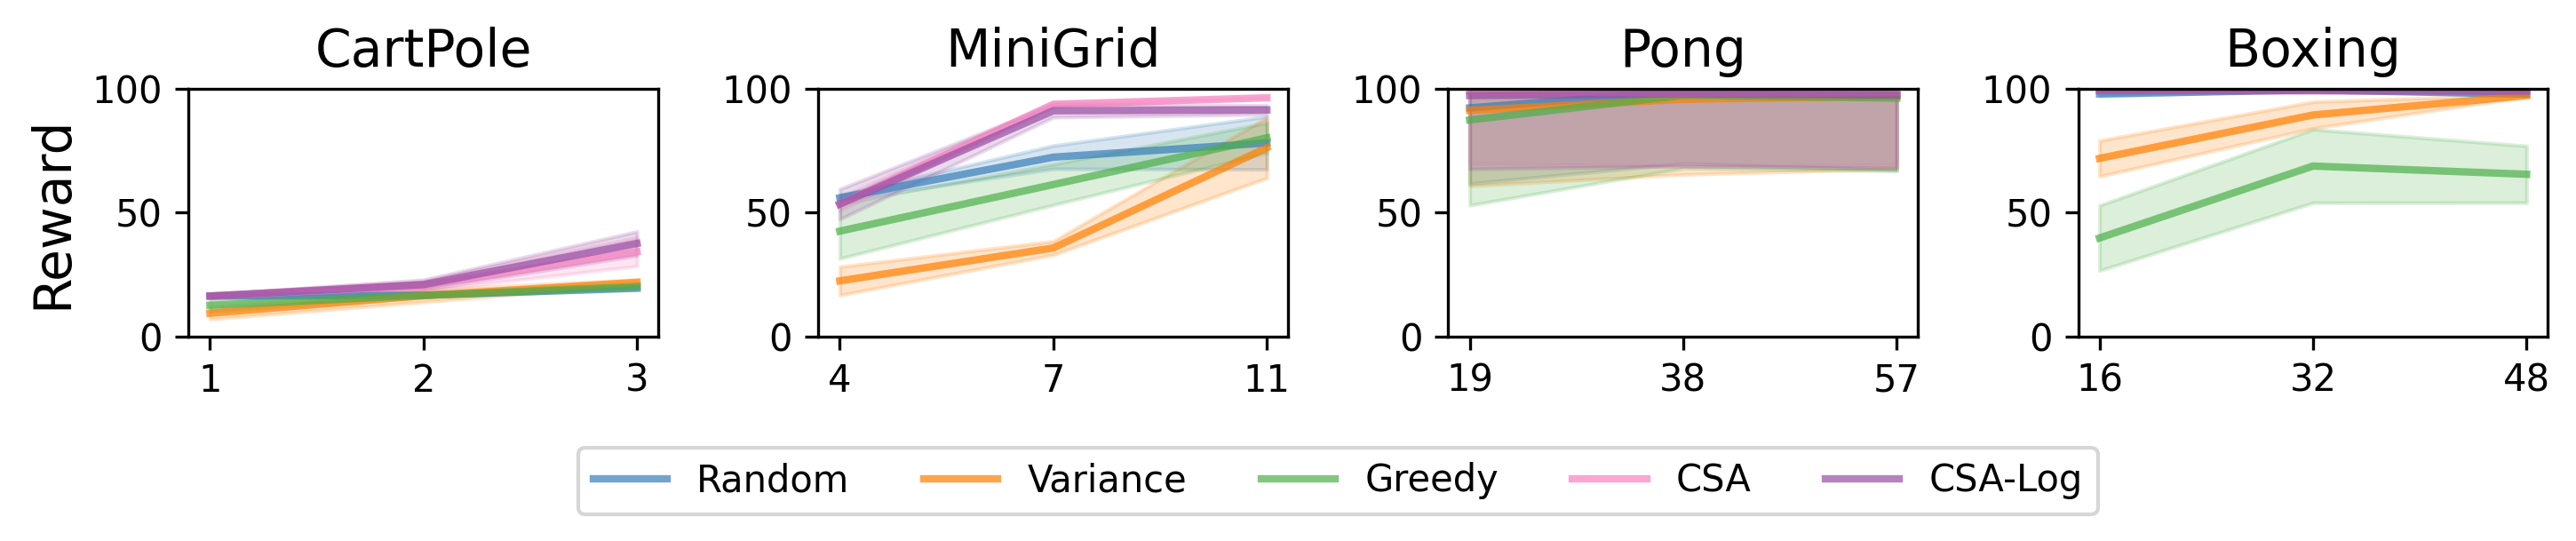

In [66]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]
y_labels = [["" for i in range(5)]]
y_labels[0][0] = "Reward"

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100],[0,100],[0,100],[0,100],[0,100]]],
    'x_ticks': [[[[0,1,2],[round(num_concepts_selected[imperfect_environments[i]]*[0.33,0.66,1][j]) for j in range(3)]] for i in range(4)] for j in range(1)],
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,y_labels=y_labels)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    y_vals = all_performances_k[i]

    x_groups = [list(range(len(j))) for j in y_vals]

    plot_line(ax[0][i],x_groups,y_vals,all_performances_k_std[i], [methods_to_nice[m] for m in imperfect_methods],line_format)
    
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.23,-0.1),'fontsize': 18}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_varied_k.pdf",dpi=300, bbox_inches='tight')

In [83]:
all_performances_k[2][3][0]/all_performances_k[2][1][0]

1.0847267625585704

In [85]:
all_performances_k[3][3][0]/all_performances_k[3][2][0]

2.5014182701476657

In [88]:
all_performances_k_std[3]

[[0.9463550515355492, 0.06639440865881199, 0.5491241101760399],
 [7.210478432233018, 5.368823088105741, 0.37574071764709654],
 [13.169406349556057, 14.824312675116788, 11.475663414394791],
 [0.10528881369821962, 0.08552102706603382, 0.25949341274228865],
 [0.03159600918213988, 0.08014426415682764, 0.0]]

In [149]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid","multiple_log"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_k = []
for j,e in enumerate(perfect_environments):
    temp_env = []
    for m in perfect_methods:
        temp = []

        for fraction_selected in [0.33,0.66,1]:
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                        'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                        'method': m, 'gold_timesteps': gold_timesteps[e]})


            if len(matching_params) == 0:
                matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                            'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                            'method': m, 'gold_timesteps': gold_timesteps[e], 'experiment': 'perfect_comparison'})

            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
            print("Perfect",e,m,round(num_concepts_selected[e]*fraction_selected),[i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])],np.mean( [len(matching_params[i][m]['concepts']) for i in range(len(matching_params))]))

            if np.isnan(performance):
                performance = 0
            temp.append(performance)
        temp_env.append(temp)
    all_performances_k.append(temp_env)


Perfect cart_pole random 1 [112.26727066817666, 112.20744081172492, 75.43149129447389, 81.05126118795769, 112.21468926553672, 88.20726306465899] 1.0
Perfect cart_pole random 2 [164.70364238410596, 89.7954954954955, 164.03471074380164, 165.74376039933443, 75.75930144267274, 83.8357203032856] 2.0
Perfect cart_pole random 3 [173.9106830122592, 171.32413793103447, 172.8411867364747] 3.0
Perfect cart_pole entropy 1 [39.99559647718174, 75.43149129447389, 40.17538213998391, 112.26727066817666, 31.459553037456722, 33.078476821192055] 1.0
Perfect cart_pole entropy 2 [52.17425431711146, 110.55937846836848, 92.26851851851852, 113.44697833523375, 41.23347107438016, 101.55816326530612] 2.0
Perfect cart_pole entropy 3 [104.6621052631579, 105.5270413573701, 106.8741935483871] 3.0
Perfect cart_pole greedy 1 [112.21468926553672, 75.43149129447389, 81.05126118795769, 29.549141503848432, 32.04201411161001, 112.26727066817666] 1.0
Perfect cart_pole greedy 2 [98.65609514370664, 112.54761904761905, 75.33711

In [152]:
num_concepts_selected = [[1,2,3],[3,6,11],[57//4,57//2,57],[12,24,48],[2,5,10]]
accuracies = [0.75,0.85,0.95]
max_perf = [i+0.001 for i in all_baselines]
max_perf[3] = 100
max_perf[2] = 21
heatmap_by_env = [[[0 for k in range(len(num_concepts_selected[i]))] for j in accuracies] for i in range(len(perfect_environments))]

for i,e in enumerate(perfect_environments):
    for j,acc in enumerate(accuracies):
        for k,n in enumerate(num_concepts_selected[i]):
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e, 'concept_accuracy': acc,
                        'num_concepts_selected': n, 'training_timesteps': training_times[e]})
            print(e,acc,n,len(matching_params),[m['multiple']['reward'] for m in matching_params],round(np.mean([m['multiple']['reward'] for m in matching_params])/max_perf[i],2)*100)
            if len(matching_params) > 0 and 'multiple' in matching_params[0]:
                heatmap_by_env[i][j][k] = round(method_scales[i](np.mean([m['multiple']['reward'] for m in matching_params])))

cart_pole 0.75 1 3 [41.38704318936877, 38.26825518831668, 45.68135904499541] 42.0
cart_pole 0.75 2 3 [41.06286186931348, 47.113421550094515, 51.714880332986475] 47.0
cart_pole 0.75 3 3 [51.22966014418126, 95.72093023255815, 47.97019230769231] 65.0
cart_pole 0.85 1 3 [43.05613126079447, 43.91879964695499, 54.2308533916849] 47.0
cart_pole 0.85 2 3 [75.94036697247707, 45.40582347588717, 50.81122448979592] 57.99999999999999
cart_pole 0.85 3 3 [55.67673378076063, 200.70781893004116, 73.02058823529411] 110.00000000000001
cart_pole 0.95 1 3 [43.687445127304656, 43.90669014084507, 61.17589175891759] 50.0
cart_pole 0.95 2 3 [60.55596107055961, 124.36934673366834, 47.04824976348155] 78.0
cart_pole 0.95 3 3 [58.996437054631826, 142.70058139534885, 361.23703703703706] 189.0
mini_grid 0.75 3 3 [0.34474487615874294, 0.27174559475361615, 0.3069807401133908] 0.0
mini_grid 0.75 6 3 [0.338770422638512, 0.31388695721609006, 0.3521259522458674] 0.0
mini_grid 0.75 11 3 [0.09579582363712816, 0.1288161433798

mini_grid 0.95 3 3 [0.22842160046100615, 0.2774691737319966, 0.3181814293244055] 0.0
mini_grid 0.95 6 3 [0.7633638996999019, 0.6993610616881392, 0.7259176296484869] 1.0
mini_grid 0.95 11 3 [0.9352531196660837, 0.9347532143042389, 0.9325986394639136] 1.0
pong 0.75 14 3 [-20.223300970873787, -20.33653846153846, -19.75] -96.0
pong 0.75 28 3 [-20.040816326530614, -19.766666666666666, -19.026315789473685] -93.0
pong 0.75 57 3 [-19.155844155844157, -19.1625, -19.4] -92.0
pong 0.85 14 3 [-20.153846153846153, -19.926315789473684, -19.386363636363637] -94.0
pong 0.85 28 3 [-18.28358208955224, -17.67241379310345, -19.98936170212766] -89.0
pong 0.85 57 3 [-17.678571428571427, -17.854545454545455, -17.12962962962963] -84.0
pong 0.95 14 3 [-20.061855670103093, -19.2183908045977, -17.718309859154928] -90.0
pong 0.95 28 3 [-16.428571428571427, -19.650602409638555, -16.282608695652176] -83.0
pong 0.95 57 3 [-15.128205128205128, -15.486486486486486, -12.074074074074074] -68.0
boxing 0.75 12 3 [2.875, 3

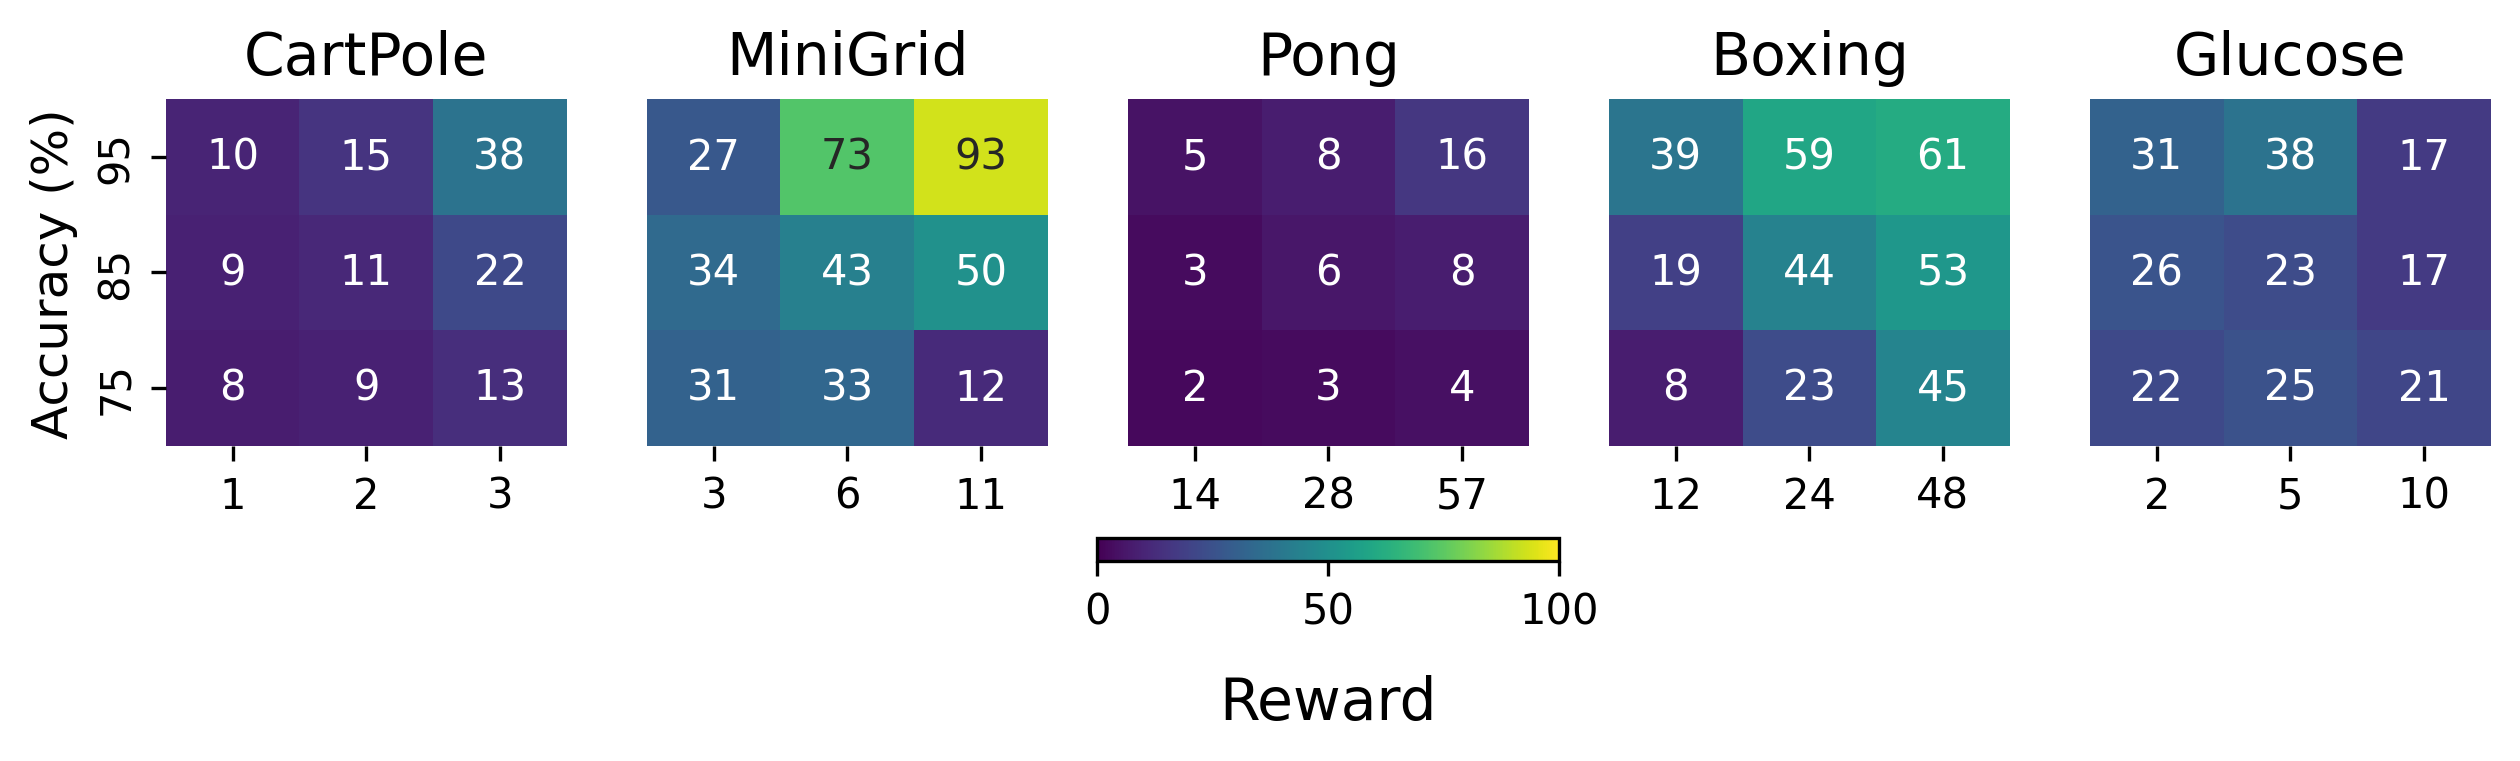

In [164]:
plot_dimensions = (1,len(perfect_environments))
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(len(perfect_environments))] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = [[name_to_nice[i] for i in perfect_environments]]
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

import matplotlib as mpl

fig, ax = create_axes(plot_dimensions, overall_format, titles=titles)

# Draw all heatmaps WITHOUT colorbars
for i in range(len(perfect_environments)):
    annot = ["75","85","95"] 
    if i!=0:
        annot = [] 
    sns.heatmap(
        heatmap_by_env[i],
        ax=ax[0][i],
        cmap="viridis",
        xticklabels=num_concepts_selected[i],
        yticklabels=annot,
        vmin=0, vmax=100,   # ensure consistent scaling
        cbar=False,
        annot=True
    )
    ax[0][i].invert_yaxis()

# ---- GLOBAL HORIZONTAL COLORBAR (0 to 1) ----
norm = mpl.colors.Normalize(vmin=0, vmax=100)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[a for row in ax for a in row],
    orientation='horizontal',
    fraction=0.05,    # thinner bar
    pad=0.20          # spacing from subplots
)
cbar.set_label("Reward",fontsize=14,labelpad=10)

ax[0][0].set_ylabel("Accuracy (%)", fontsize=12)

fig.savefig(
    "../../results/figures/num_concepts_accuracy.pdf",
    dpi=300,
    bbox_inches='tight')


In [189]:
num_concepts_selected = 11
concept_accuracies = [0.75,0.85,0.95]
environment = "mini_grid"
rewards = []
stds = []

for acc in concept_accuracies:
    temp = []
    temp_std = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': num_concepts_selected, 'concept_accuracy':acc, 'training_timesteps': t})
        print(acc,t,len(matching_params))
        temp.append(method_scales[1](np.mean([i['multiple']['reward'] for i in matching_params])))
        temp_std.append(method_scales[1](np.std([i['multiple']['reward'] for i in matching_params]))/len(matching_params)**.5)

    rewards.append(temp)
    stds.append(temp_std)
rewards_accuracy = np.array(rewards)
std_accuracy = np.array(stds)

0.75 250000 3
0.75 500000 3
0.75 750000 3
0.75 1000000 3
0.85 250000 3
0.85 500000 3
0.85 750000 3
0.85 1000000 3
0.95 250000 3
0.95 500000 3
0.95 750000 3
0.95 1000000 3


In [190]:
acc = 0.9
num_concepts_selected = [3,6,11]
environment = "mini_grid"
total_concepts = 44
rewards = []
stds_concepts = []

for n in num_concepts_selected:
    temp = []
    temp_std = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': n, 'concept_accuracy':0.95, 'training_timesteps': t})
        print(n,t,len(matching_params))
        temp.append(method_scales[1](np.mean([i['multiple']['reward'] for i in matching_params])))
        temp_std.append(method_scales[1](np.std([i['multiple']['reward'] for i in matching_params]))/len(matching_params)**.5)

    rewards.append(temp)
    stds_concepts.append(temp_std)
rewards_num_concepts = np.array(rewards)
stds_concepts = np.array(stds_concepts)
rewards_num_concepts

3 250000 3
3 500000 3
3 750000 3
3 1000000 3
6 250000 3
6 500000 3
6 750000 3
6 1000000 3
11 250000 3
11 500000 3
11 750000 3
11 1000000 3


array([[10.57174097, 27.46907345, 32.98550754, 35.64520518],
       [38.25154443, 72.95475303, 77.62362377, 79.57873018],
       [71.92803478, 93.42016578, 93.91971068, 94.16691514]])

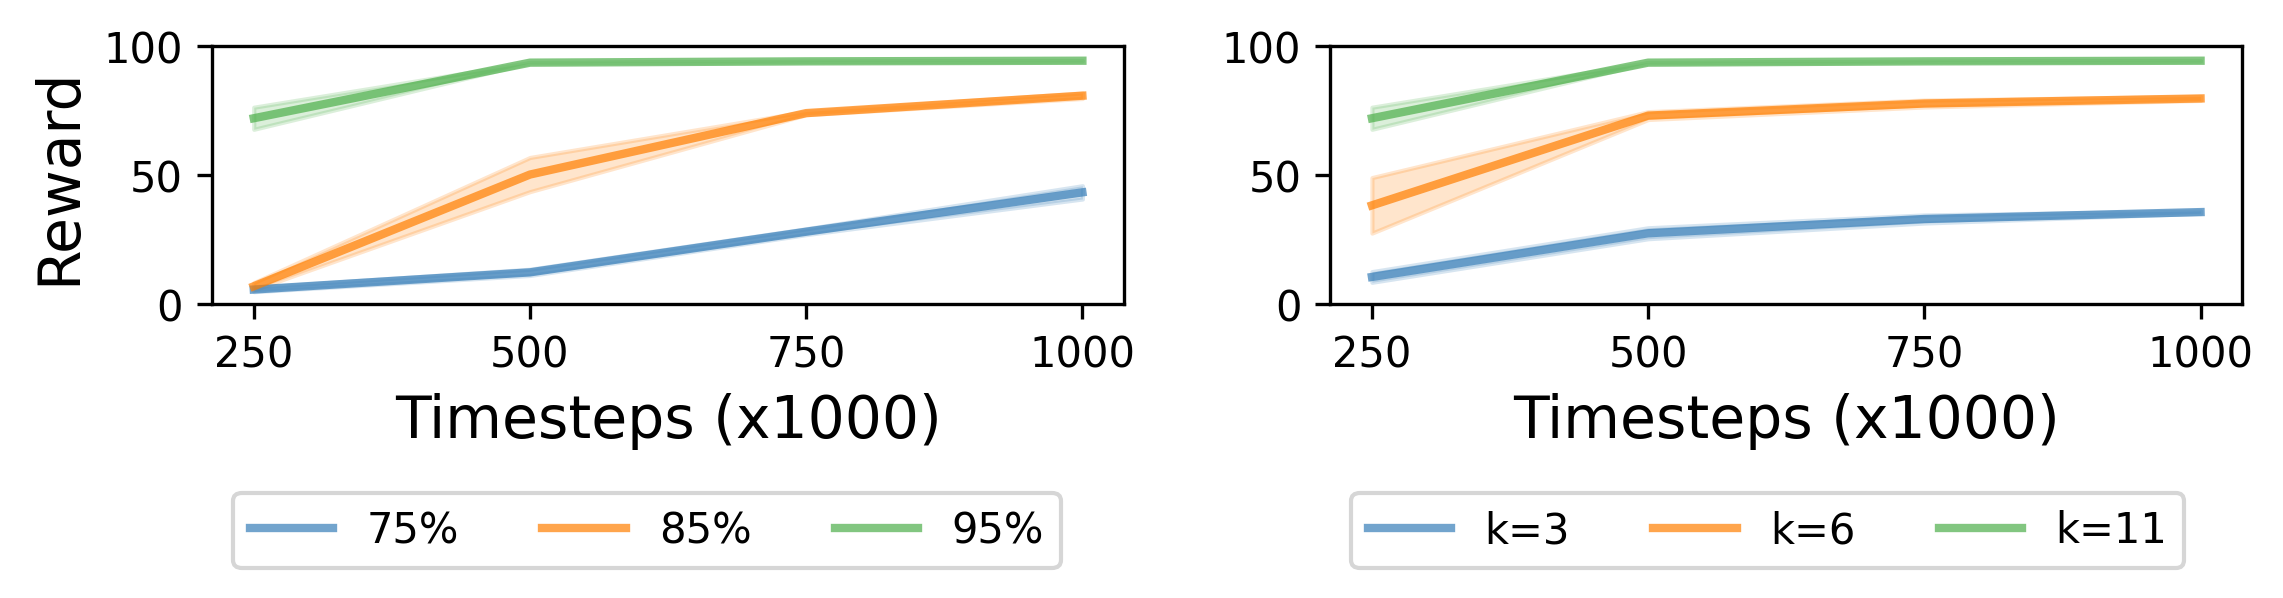

In [191]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,2)
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(2)] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res


sup_y_label = ""
overall_format = {'figsize':(8,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[[0,1,2,3],["250","500","750","1000"]] for i in range(2)]],
    'y_ticks': [[[[0,50,100],["0","50","100"]] for i in range(2)]],
    'y_lim': [[[0,100] for i in range(2)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,y_labels=[["Reward",""]],x_labels=[["Timesteps (x1000)","Timesteps (x1000)"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(4)) for i in range(3)]
y_vals = rewards_accuracy
y_std = std_accuracy
plot_line(ax[0][0],x_groups,y_vals,y_std,["{}%".format(round(i*100)) for i in concept_accuracies],line_format)

x_groups = [list(range(4)) for i in range(3)]
y_vals = rewards_num_concepts 
y_std = stds_concepts
plot_line(ax[0][1],x_groups,y_vals,y_std,["k={}".format(i) for i in num_concepts_selected],line_format)


legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0,-1.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/accuracy_num_concepts.pdf",dpi=300, bbox_inches='tight')

In [120]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid","multiple_log"]

intervention_probability = [0.25,0.5,0.75]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

cart_pole_interventions = []
e = "cart_pole"
cart_pole_interventions.append(all_performances_imperfect[0][1:])
cart_pole_interventions_std = []
cart_pole_interventions_std.append(all_performances_imperfect[0][1:])
for i in intervention_probability:
    temp = []
    temp_std = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': m, 'intervention_prob': i})
        if len(matching_params) > 0:
            performance = method_scales[0](np.mean([i[m]['reward'] for i in matching_params]))
            temp.append(performance)

            performance = method_scales[0](np.mean([i[m]['reward'] for i in matching_params]))/len(matching_params)**.5
            temp_std.append(performance)
        else:
            temp.append(0.0001)
            temp_std.append(0)
    cart_pole_interventions.append(temp)
    cart_pole_interventions_std.append(temp_std)
intervention_probability.append(1.0)
intervention_probability = [0.0] + intervention_probability
cart_pole_interventions.append((all_performances_perfect[0][1:]+all_performances_perfect[0][-1:]))
cart_pole_interventions_std.append((all_performances_perfect_std[0][1:]+all_performances_perfect_std[0][-1:]))

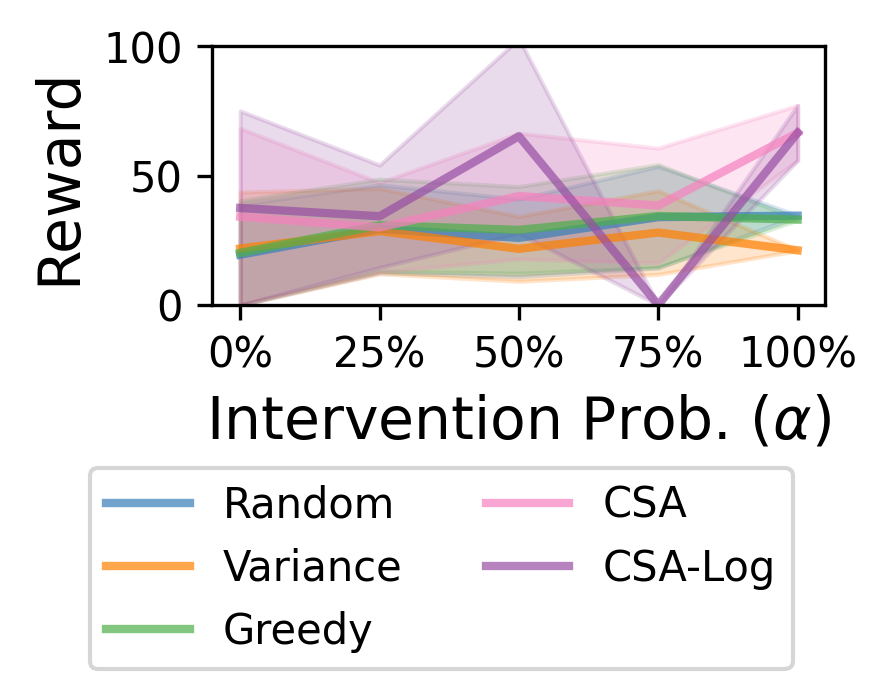

In [139]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)
titles = [[""]]
y_labels = [["Reward"]]

sup_y_label = ""
overall_format = {'figsize':(3.3,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(intervention_probability))),["0%","25%","50%","75%","100%"]] for i in range(5)] for j in range(1)],
    'y_lim': [[[0,100]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,x_labels=[["Intervention Prob. ($\\alpha$)"]],y_labels=y_labels)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(len(intervention_probability))) for j in imperfect_methods]
y_vals = np.array(cart_pole_interventions).T
y_std = np.array(cart_pole_interventions_std).T
plot_line(ax[0][0],x_groups,y_vals,y_std,['Random','Variance','Greedy','CSA','CSA-Log'],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 2, 'bbox_to_anchor': (0.13,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/intervention_percent.pdf",dpi=300, bbox_inches='tight')


In [144]:
cart_pole_interventions[2][3]/cart_pole_interventions[2][2],cart_pole_interventions[2][4]/cart_pole_interventions[2][2]

(1.4508811755034787, 2.247013859554201)

In [148]:
cart_pole_interventions[3][3]/cart_pole_interventions[3][2],cart_pole_interventions[3][4]/cart_pole_interventions[3][2]

(1.1180201239172616, 2.9066120907616515e-06)

In [10]:
imperfect_methods = ["random","entropy","greedy","lp_hybrid","multiple_log"]


In [123]:
import numpy as np

# ------------------------
# Global config
# ------------------------
ENV_CONFIG = {
    "cart_pole": dict(timesteps=training_times["cart_pole"], scale_idx=0),
    "mini_grid": dict(timesteps=250_000, scale_idx=1),
    "pong":      dict(timesteps=4_000_000, scale_idx=2),
    "boxing":    dict(timesteps=2_000_000, scale_idx=3),
}

INTERVENTION_PROBS = [0.25, 0.5, 0.75]

NUM_CONCEPTS = {
    'cart_pole': 3,
    'mini_grid': 11,
    'pong': 57,
    'boxing': 48,
}

# ------------------------
# Core helpers
# ------------------------
def get_method_performance(env, p):
    """Return reward per method at intervention prob p."""
    cfg = ENV_CONFIG[env]
    out = []
    for m in imperfect_methods:
        params = get_results_matching_parameters(
            "intervention", "",
            dict(
                environment_string=env,
                training_timesteps=cfg["timesteps"],
                num_concepts_selected=NUM_CONCEPTS[env],
                method=m,
                intervention_prob=p,
            )
        )
        if len(params) > 0:
            r = np.mean([i[m]["reward"] for i in params])
            out.append(method_scales[cfg["scale_idx"]](r))
        else:
            out.append(1e-4)
    return out


def compute_accuracy_tradeoff(env):
    """Return baseline_combo, intervention_combo."""
    cfg = ENV_CONFIG[env]

    # --- baseline + intervention rewards ---
    baseline_rewards = all_performances_imperfect[0][1:]
    intervention_rewards = get_method_performance(env, 0.5)

    # --- concept accuracies ---
    params = get_results_matching_parameters(
        "intervention", "",
        dict(
            environment_string=env,
            training_timesteps=cfg["timesteps"],
            num_concepts_selected=NUM_CONCEPTS[env],
            method="multiple",
            intervention_prob=0.5,
        )
    )
    accuracies = np.array(params[0]["concept_accuracy"])

    selected = []
    for m in imperfect_methods:
        p = get_results_matching_parameters(
            "intervention", "",
            dict(
                environment_string=env,
                training_timesteps=cfg["timesteps"],
                num_concepts_selected=NUM_CONCEPTS[env],
                method=m,
                intervention_prob=0.5,
            )
        )
        print(env,m,len(p))
        selected.append(p[0][m]["concepts"] if len(p) > 0 else [0])

    baseline_acc = np.array([np.mean(accuracies[i]) for i in selected])

    # intervention-adjusted accuracy
    p = 0.5
    k = NUM_CONCEPTS[env]
    intervention_acc = np.array([
        np.mean(p * np.ones(k) + (1 - p) * accuracies[i])
        for i in selected
    ])

    baseline_combo = np.column_stack([baseline_acc, baseline_rewards])
    
    intervention_combo = np.column_stack([intervention_acc, intervention_rewards])

    return baseline_combo, intervention_combo


# ------------------------
# Compute all environments
# ------------------------
results = {
    env: compute_accuracy_tradeoff(env)
    for env in ["cart_pole", "mini_grid", "pong", "boxing"]
}


cart_pole random 3
cart_pole entropy 3
cart_pole greedy 3
cart_pole lp_hybrid 3
cart_pole multiple_log 3
mini_grid random 3
mini_grid entropy 3
mini_grid greedy 3
mini_grid lp_hybrid 3
mini_grid multiple_log 3
pong random 3
pong entropy 3
pong greedy 3
pong lp_hybrid 3
pong multiple_log 3
boxing random 3
boxing entropy 3
boxing greedy 3
boxing lp_hybrid 3
boxing multiple_log 3


In [127]:
results["cart_pole"][1][-1][1]/results["cart_pole"][1][-3][1]

2.247013859554201

In [129]:
results["mini_grid"][1][-2][1]/results["mini_grid"][1][0][1]

1.3270549245628567

In [136]:
results["boxing"][1][-2][1]/results["boxing"][1][1][1]

0.9268697661718116

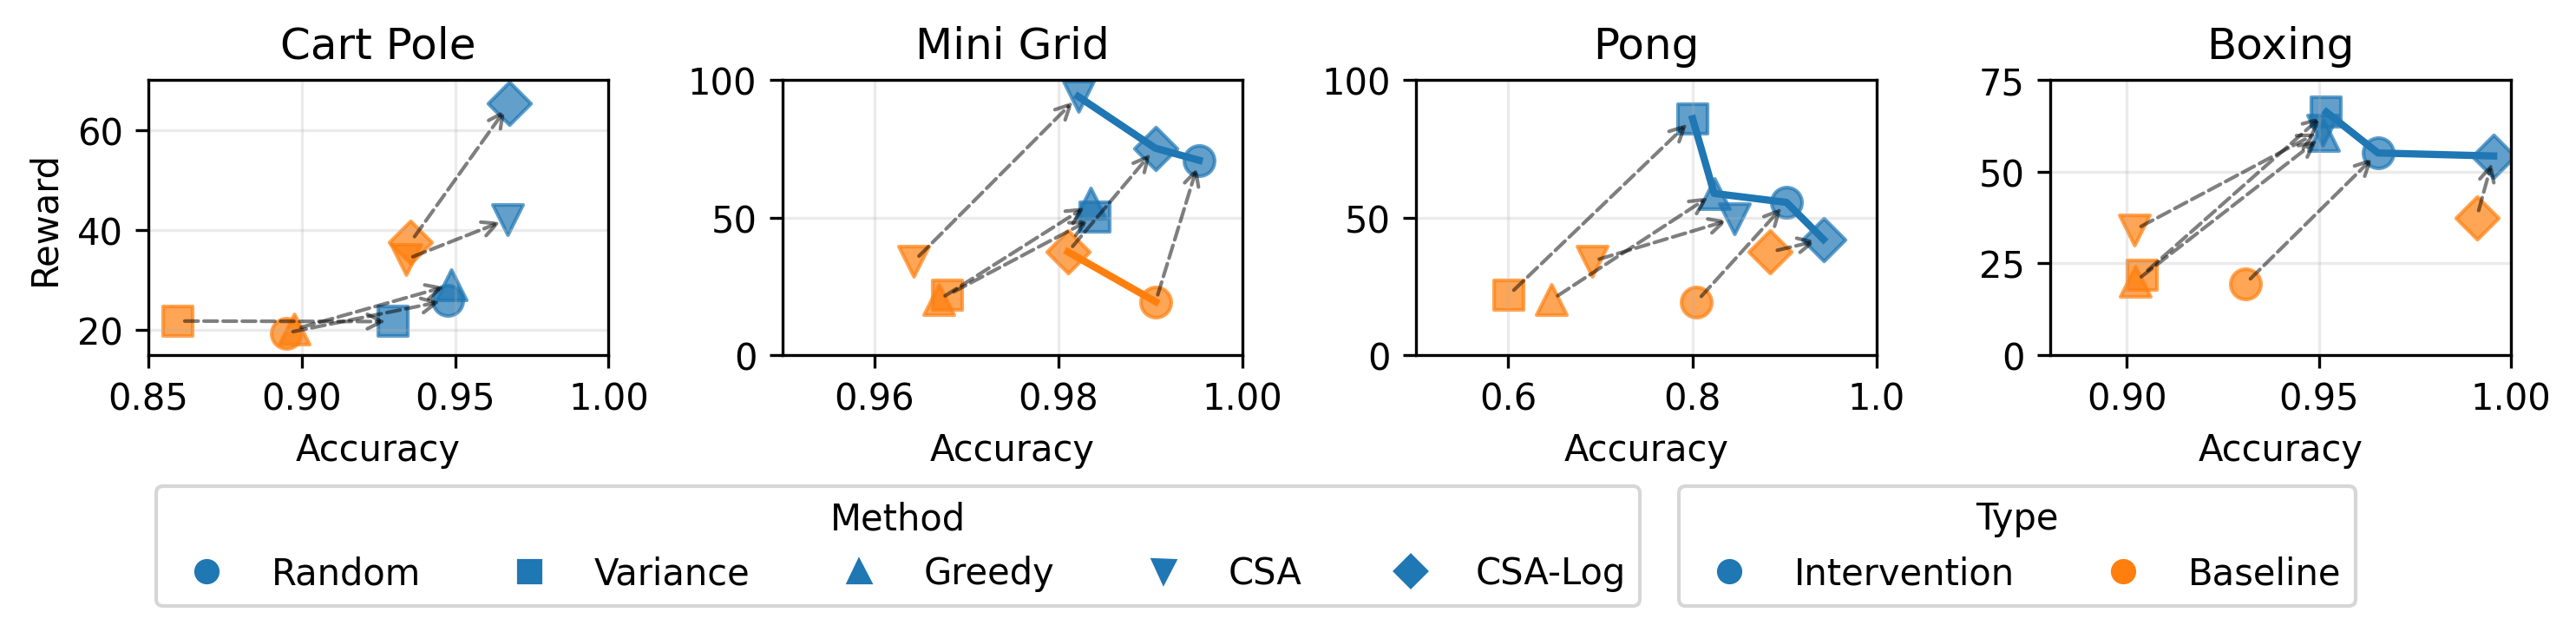

In [12]:
def pareto_front(points):
    pts = points[points[:, 0].argsort()[::-1]]
    front = [pts[0]]
    for p in pts[1:]:
        if p[1] >= front[-1][1]:
            front.append(p)
    return np.array(front)


def plot_env(ax, baseline, intervention, title, xlim, ylim):
    markers = ['o', 's', '^', 'v', 'D']

    for i, (x, y) in enumerate(intervention):
        ax.scatter(x, y, marker=markers[i], s=70, color='C0', alpha=0.7)
    for i, (x, y) in enumerate(baseline):
        ax.scatter(x, y, marker=markers[i], s=70, color='C1', alpha=0.7)

    ax.plot(*pareto_front(intervention).T, lw=2)
    ax.plot(*pareto_front(baseline).T, lw=2)

    for b, i in zip(baseline, intervention):
        ax.annotate("", xy=i, xytext=b,
                    arrowprops=dict(arrowstyle="->", ls="--", lw=1, alpha=0.5))

    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel("Accuracy")
    if title == "Cart Pole":
        ax.set_ylabel("Reward")
    ax.grid(alpha=0.25)


# ------------------------
# Figure
# ------------------------
fig, axes = plt.subplots(1, 4, figsize=(10, 2))

PLOT_CONFIG = {
    "cart_pole": ([0.85, 1.0], [15, 70]),
    "mini_grid": ([0.95, 1.0], [0, 100]),
    "pong":      ([0.5, 1.0],  [0, 100]),
    "boxing":    ([0.88, 1.0], [0, 75]),
}

for ax, env in zip(axes, ["cart_pole", "mini_grid", "pong", "boxing"]):
    baseline, intervention = results[env]
    plot_env(ax, baseline, intervention, env.replace("_", " ").title(),
             *PLOT_CONFIG[env])

# ------------------------
# Legends
# ------------------------
color_handles = [
    mlines.Line2D([], [], color='C0', marker='o', linestyle='None', label='Intervention'),
    mlines.Line2D([], [], color='C1', marker='o', linestyle='None', label='Baseline')
]

method_names = ['Random', 'Variance', 'Greedy', 'CSA', 'CSA-Log']
markers = ['o', 's', '^', 'v', 'D']
method_handles = [
    mlines.Line2D([], [], color='C0', marker=markers[i], linestyle='None',
                  label=method_names[i])
    for i in range(len(method_names))
]

fig.legend(handles=color_handles, loc="upper center", ncol=2, title="Type",bbox_to_anchor=(0.78,0.075))
fig.legend(handles=method_handles, loc="upper center", ncol=5, title="Method",bbox_to_anchor=(0.35,0.075))

plt.tight_layout()
plt.savefig("../../results/figures/intervention_comparison.pdf", dpi=300,bbox_inches='tight')
plt.show()


In [185]:
gold_timesteps = [100000,250000,500000]
methods = ["entropy","greedy","lp_hybrid","multiple_log"]
e = "mini_grid"

performance_by_gold = []
for m in methods:
    temp = []
    for g in gold_timesteps:
        matching_params = get_results_matching_parameters("ablations","",{'environment_string': e,'gold_timesteps':g,
                                                                    'method': m})
        if len(matching_params) > 0:
            val = method_scales[1](np.mean([i[m]['reward'] for i in matching_params]))
        else:
            val = 0
        temp.append(val)
    performance_by_gold.append(temp)
np.array(performance_by_gold)

array([[50.89416337, 46.68626125, 28.38803879],
       [35.9778969 , 49.29992781, 60.27967919],
       [92.35991415, 92.78283015, 93.29761926],
       [52.20582694, 72.59516914, 91.12748544]])

In [186]:
performance_by_gold

[[50.8941633686269, 46.68626124607489, 28.388038785087648],
 [35.97789689972905, 49.299927809351104, 60.27967919405567],
 [92.35991415454671, 92.78283015066032, 93.29761925699627],
 [52.20582693576093, 72.59516914342476, 91.12748543608967]]

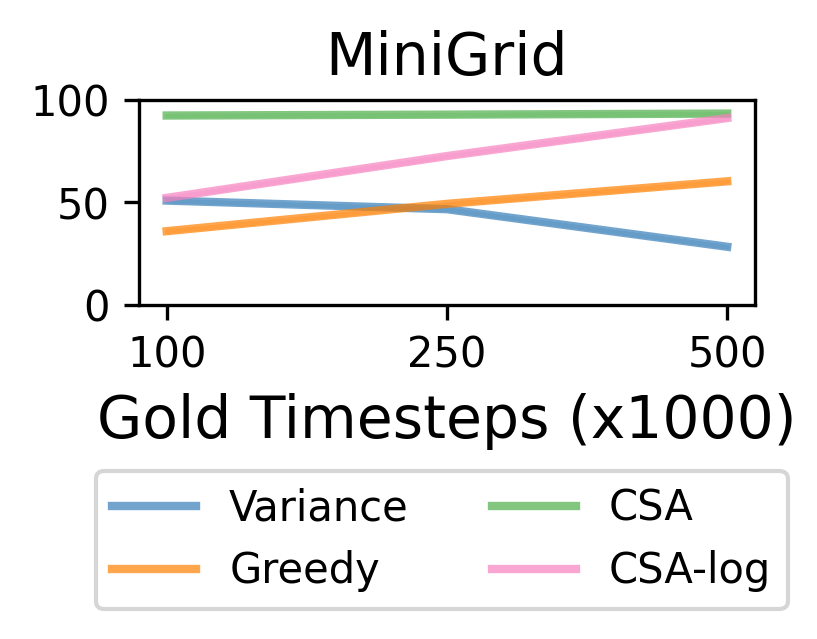

In [24]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)
titles = [["MiniGrid"]]

sup_y_label = ""
overall_format = {'figsize':(3,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(gold_timesteps))),[str(g//1000) for g in gold_timesteps]] for i in range(5)] for j in range(1)],
    'y_lim': [[[0,100]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,x_labels=[["Gold Timesteps (x1000)"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(3)) for j in range(4)]
y_vals = np.array(performance_by_gold)
y_std = np.zeros(y_vals.shape)
plot_line(ax[0][0],x_groups,y_vals,y_std,["Variance","Greedy","CSA","CSA-log"],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 2, 'bbox_to_anchor': (0.15,-0.15),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/gold_timesteps.pdf",dpi=300, bbox_inches='tight')

In [83]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["perfect_concepts","lp_hybrid","policy_selection_lp","lp_old","completeness","lp_policy"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["imperfect_concepts","lp_hybrid","policy_selection_lp","lp_old","completeness","lp_policy"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

gold_timesteps = {
    'cart_pole': 4_000_000,
    'mini_grid': 1_000_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 30_000_000,
}


all_performances_perfect_lp = []
all_performances_imperfect_lp = []

all_baselines = []

for j,e in enumerate(perfect_environments):
    temp = []
    for m in perfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Perfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])

        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)
    all_performances_perfect_lp.append(temp)

for j,e in enumerate(imperfect_environments):
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])
        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

    all_performances_imperfect_lp.append(temp)

for j,e in enumerate(imperfect_environments):
    matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],'gold_timesteps': gold_timesteps[e],
                                                                'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison', 'method': 'ground_truth'})
    m = 'ground_truth'
    print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed']) for i in matching_params if m in i])
    performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
    all_baselines.append(performance)
all_baselines.append(0)

Perfect cart_pole perfect_concepts 3 [(499.5, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.875, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.915, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])]
Perfect cart_pole lp_hybrid 3 [(204.00821355236138, 42, [1, 4, 7]), (413.1386554621849, 44, [1, 7, 10]), (381.36293436293437, 43, [0, 6, 10])]
Perfect cart_pole policy_selection_lp 3 [(330.0816326530612, 44, [4, 6, 7]), (450.79245283018867, 43, [4, 6, 7]), (440.56363636363636, 42, [3, 6, 7])]
Perfect cart_pole lp_old 3 [(395.1951219512195, 43, [4, 7, 10]), (118.69064748201438, 44, [3, 4, 10]), (122.06896551724138, 42, [2, 4, 10])]
Perfect cart_pole completeness 0 []
Perfect cart_pole lp_policy 0 []
Perfect mini_grid perfect_concepts 3 [(0.9595455418019246, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]), (0.9595675355798743, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Perfect pong policy_selection_lp 3 [(15.028571428571428, 44, [6, 18, 56, 57, 61, 65, 68, 72, 73, 74, 77, 80, 81, 82, 84, 85, 86, 89, 92, 93, 94, 96, 97, 98, 101, 104, 105, 106, 108, 109, 110, 112, 113, 116, 117, 119, 120, 122, 125, 126, 127, 129, 132, 134, 138, 139, 140, 143, 151, 152, 153, 155, 163, 164, 183, 210, 222]), (4.777777777777778, 43, [6, 27, 53, 56, 57, 61, 68, 69, 72, 73, 74, 77, 80, 81, 84, 85, 86, 89, 92, 93, 94, 96, 97, 98, 101, 104, 105, 106, 109, 110, 112, 113, 116, 117, 118, 119, 120, 122, 125, 127, 129, 132, 134, 139, 140, 141, 143, 151, 153, 155, 162, 163, 165, 167, 176, 200, 222]), (18.083333333333332, 42, [15, 61, 63, 68, 72, 73, 74, 77, 82, 84, 85, 86, 89, 93, 94, 96, 97, 98, 101, 104, 105, 108, 109, 110, 113, 116, 117, 118, 119, 120, 125, 126, 128, 129, 131, 132, 134, 138, 139, 140, 141, 151, 152, 153, 163, 164, 165, 167, 176, 177, 179, 188, 189, 191, 200, 208, 220])]
Perfect pong lp_old 3 [(-20.0, 42, [15]), (-20.666666666666668, 43, [15, 61, 74]), (17.8333333

5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1


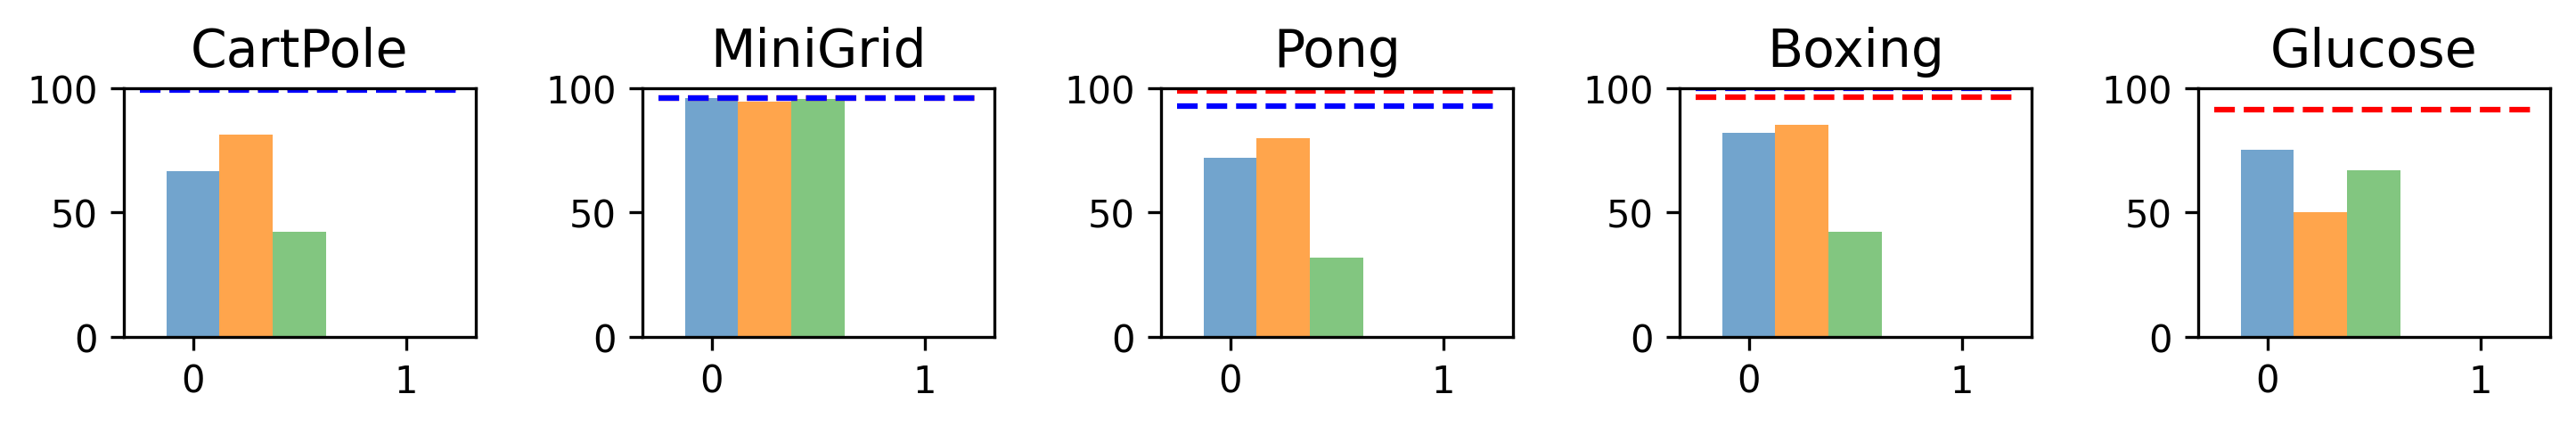

In [84]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(5)]]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(perfect_environments)):
    x_groups = list(range(len(all_performances_perfect_lp[i][:-1])))
    y_vals = all_performances_perfect_lp[i][1:]


    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], {
        0: 'LP',
        1: 'Policy-LP',
        2: 'Q-LP',
        3: 'Completeness',
        4: 'LP Policy'
    },bar_format)
    
    ax[0][i].hlines(all_performances_perfect_lp[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    
    if i!=len(perfect_environments)-1:
        ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

# legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.1,-0.1),'fontsize': 14}
# create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/perfect_other_methods.pdf",dpi=300, bbox_inches='tight')

5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1


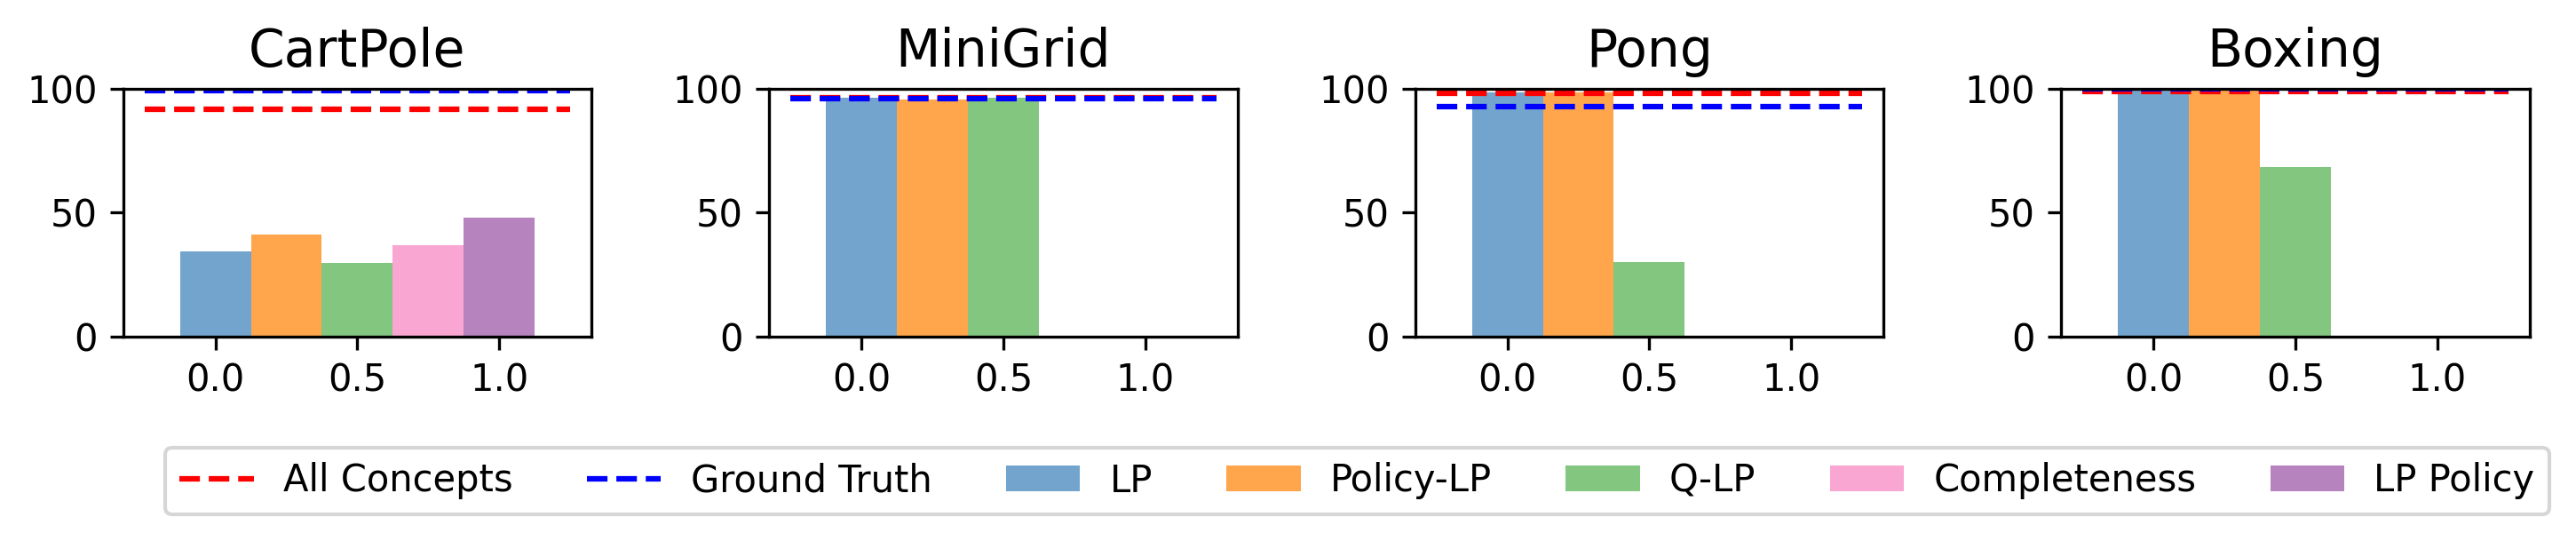

In [85]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(4)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect_lp[i][:-1])))
    y_vals = all_performances_imperfect_lp[i][1:]

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))],  {
        0: 'LP',
        1: 'Policy-LP',
        2: 'Q-LP',
        3: 'Completeness',
        4: 'LP Policy'
    },bar_format)
    
    ax[0][i].hlines(all_performances_imperfect_lp[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 7, 'bbox_to_anchor': (0.075,-0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_other_methods.pdf",dpi=300, bbox_inches='tight')

In [172]:
matching_params = get_results_matching_parameters("cub","",{'num_concepts_selected': 311})
matching_params = [i for i in matching_params if 'epochs' not in i['parameters']]
perfect_lp = [[m['perfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
chosen_concepts = np.mean([m['perfect']['manual']['reward'] for m in matching_params])
similarity = [[len(set(matching_params[0]['perfect']['lp'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
perfect_lp = np.mean(perfect_lp,axis=0)
similarity = np.mean(similarity,axis=1)

KeyError: 'lp'

In [173]:
imperfect_lp = [[m['imperfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
imperfect_lp = np.mean(imperfect_lp,axis=0)
multiple_lp = [[m['imperfect']['multiple'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
multiple_lp = np.mean(multiple_lp,axis=0)

greedy = [[m['imperfect']['greedy'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
greedy = np.mean(greedy,axis=0)

random_selection = [[m['imperfect']['random'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
random_selection = np.mean(random_selection,axis=0)


chosen_concepts = np.mean([m['imperfect']['manual']['reward'] for m in matching_params])


KeyError: 'lp'

In [174]:
similarity_multiple = [[len(set(m['imperfect']['multiple'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_random= [[len(set(m['imperfect']['random'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_greedy= [[len(set(m['imperfect']['greedy'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity = [[len(set(m['perfect']['lp'][str(c)]['concepts']).intersection(set(matching_params[0]['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]

similarity_multiple = np.mean(similarity_multiple,axis=1)
similarity_random = np.mean(similarity_random,axis=1)
similarity_greedy = np.mean(similarity_greedy,axis=1)
similarity = np.mean(similarity,axis=1)

KeyError: 'multiple'

In [175]:
imperfect_lp_intervention = [[m['intervention']['lp'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
imperfect_lp_intervention = np.mean(imperfect_lp_intervention,axis=0)
multiple_lp_intervention = [[m['intervention']['multiple'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
multiple_lp_intervention = np.mean(multiple_lp_intervention,axis=0)

greedy_intervention = [[m['intervention']['greedy'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
greedy_intervention = np.mean(greedy_intervention,axis=0)

random_selection_intervention = [[m['intervention']['random'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
random_selection_intervention = np.mean(random_selection_intervention,axis=0)


chosen_concepts_intervention = [[m['intervention']['manual'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
chosen_concepts_intervention = np.mean(chosen_concepts_intervention,axis=0)


KeyError: 'multiple'

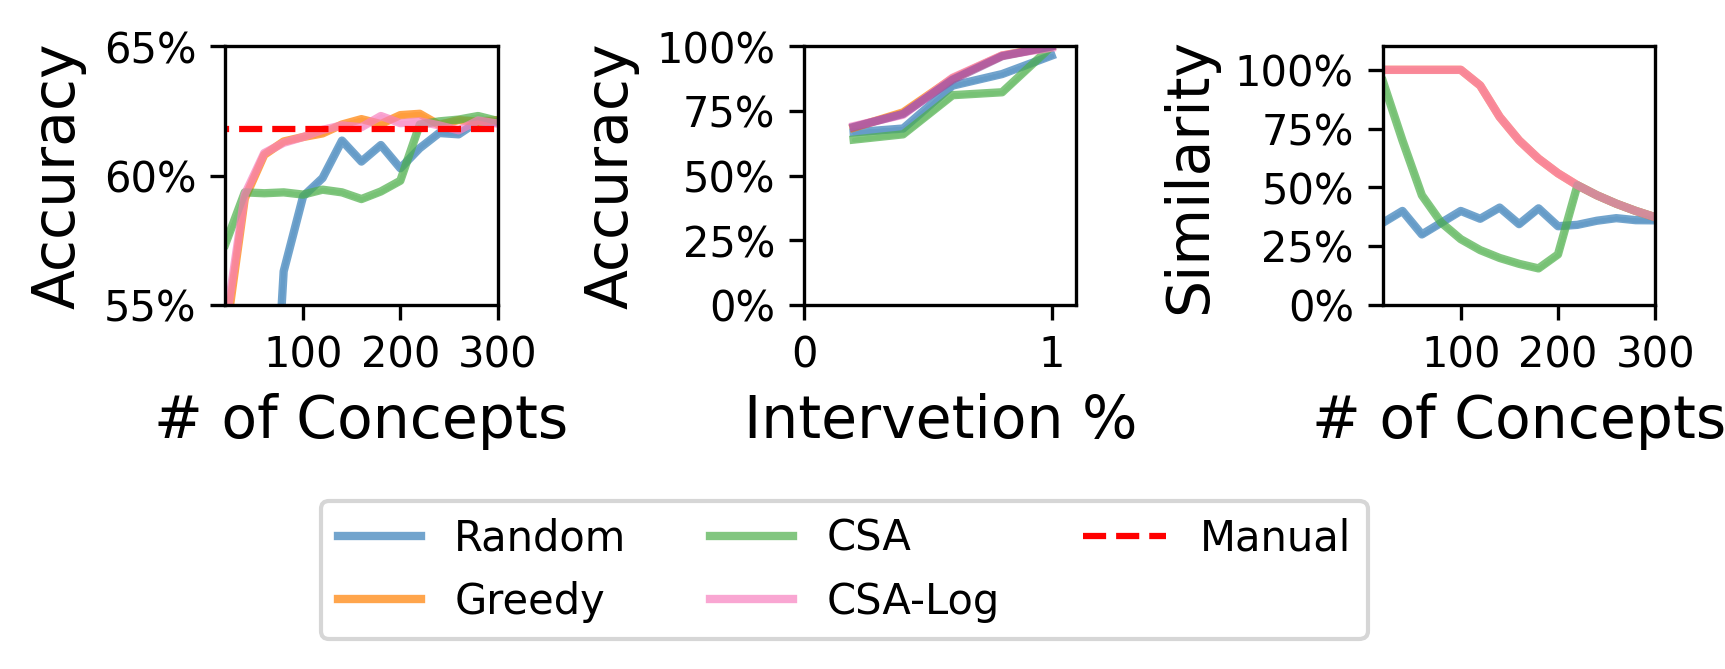

In [82]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,3)

sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_lim': [[[20,300],[0,1.1],[20,300]]],
    'y_lim': [[[0.55,0.65],[0,1],[0,1.1]]],
    'y_ticks': [[[[0.55,0.6,0.65],["55%","60%","65%"]],[[0,0.25,0.5,0.75,1],["0%","25%","50%","75%","100%"]],[[0,0.25,0.5,0.75,1],["0%","25%","50%","75%","100%"]]]],
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts","Intervetion %","# of Concepts"]],y_labels=[["Accuracy","Accuracy","Similarity"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Random","Greedy","CSA","CSA-Log"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [random_selection,greedy,imperfect_lp,multiple_lp]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
ax[0][0].hlines(chosen_concepts,0,311,label="Manual",color="red",linestyle="--")
line_format = {'color_palette': 'six_color', 'linewidth': 2}

all_labels = ["Random","Greedy","CSA","CSA-Log","Manual"]

x_groups = [[0.2,0.4,0.6,0.8,1.0] for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [random_selection_intervention,greedy_intervention,imperfect_lp_intervention,multiple_lp_intervention,chosen_concepts_intervention]]

plot_line(ax[0][1],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)


all_labels = ["Random","Greedy","CSA","CSA-Log"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(similarity)-1)] for i in range(len(x_groups[0]))] for arr in [similarity_random,similarity_greedy,similarity,similarity_multiple]]

plot_line(ax[0][2],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0.2,-0.2),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_cub.pdf",dpi=300, bbox_inches='tight')

In [193]:
import numpy as np

# -------------------------
# Load + filter experiments
# -------------------------
matching_params = get_results_matching_parameters(
    "cub", "", {"num_concepts_selected": 311}
)
matching_params = [
    m for m in matching_params if "epochs" not in m["parameters"]
]

C_VALUES = list(range(20, 311, 20))
INTERVENTIONS = [0.2, 0.4, 0.6, 0.8, 1.0]
N = len(matching_params)

# -------------------------
# Method registry
# -------------------------
METHODS = {
    "random": "Random",
    "entropy": "Variance",
    "greedy": "Greedy",
    "lp": "CSA",
    "multiple": "CSA-Log",
}

# -------------------------
# Helpers (mean + stderr)
# -------------------------
def mean_stderr_curve(params, path, xs):
    vals = np.array([
        [m[path.split("/")[0]][path.split("/")[1]][str(x)]["reward"] for x in xs]
        for m in params
    ])
    return vals.mean(axis=0), vals.std(axis=0) / np.sqrt(len(vals))


def mean_stderr_similarity(params, path, ref_path, xs):
    vals = np.array([
        [
            len(
                set(m[path.split("/")[0]][path.split("/")[1]][str(x)]["concepts"])
                & set(m[ref_path.split("/")[0]][ref_path.split("/")[1]]["concepts"])
            ) / x
            for x in xs
        ]
        for m in params
    ])
    return vals.mean(axis=0), vals.std(axis=0) / np.sqrt(len(vals))


# -------------------------
# Rewards (no intervention)
# -------------------------
rewards, rewards_stderr = {}, {}
for k, p in {
    "random": "imperfect/random",
    "greedy": "imperfect/greedy",
    "entropy": "imperfect/entropy",
    "lp": "imperfect/lp_hybrid",
    "multiple": "imperfect/multiple_log",
}.items():
    rewards[k], rewards_stderr[k] = mean_stderr_curve(
        matching_params, p, C_VALUES
    )

manual_reward = np.mean(
    [m["imperfect"]["manual"]["reward"] for m in matching_params]
)

# -------------------------
# Similarities
# -------------------------
similarities, similarities_stderr = {}, {}
for k, p in {
    "random": "imperfect/random",
    "greedy": "imperfect/greedy",
    "entropy": "imperfect/entropy",
    "lp": "imperfect/lp_hybrid",
    "multiple": "imperfect/multiple_log",
}.items():
    similarities[k], similarities_stderr[k] = mean_stderr_similarity(
        matching_params, p, "imperfect/manual", C_VALUES
    )

# -------------------------
# Intervention curves
# -------------------------
intervention_rewards, intervention_stderr = {}, {}
for k, p in {
    "random": "intervention/random",
    "greedy": "intervention/greedy",
    "entropy": "intervention/entropy",
    "lp": "intervention/lp",
    "multiple": "intervention/multiple_log",
    "manual": "intervention/manual",
}.items():
    intervention_rewards[k], intervention_stderr[k] = mean_stderr_curve(
        matching_params, p, INTERVENTIONS
    )


In [179]:
manual_reward

0.639972385226096

In [178]:
rewards

{'random': array([0.23052583, 0.4781383 , 0.54383845, 0.59463813, 0.61580946,
        0.63007709, 0.63375906, 0.63939708, 0.64089288, 0.63807387,
        0.63801634, 0.64210102, 0.64428719, 0.64284892, 0.64440226]),
 'greedy': array([0.40961915, 0.58825221, 0.62909907, 0.64002992, 0.64198596,
        0.64054769, 0.64394201, 0.64365436, 0.64359682, 0.64302152,
        0.64279139, 0.64382695, 0.64307905, 0.64492003, 0.64474744]),
 'entropy': array([0.60712231, 0.62996203, 0.63784375, 0.64169831, 0.6403751 ,
        0.64175584, 0.64164078, 0.64405707, 0.64526522, 0.64371189,
        0.64376942, 0.64399954, 0.64468991, 0.64566793, 0.64417213]),
 'lp': array([0.60441836, 0.62938672, 0.63836152, 0.63939708, 0.64020251,
        0.63945461, 0.64238868, 0.64687608, 0.64382695, 0.64492003,
        0.64584052, 0.64589806, 0.64468991, 0.64284892, 0.64313658]),
 'multiple': array([0.60499367, 0.63024968, 0.63715338, 0.64002992, 0.64060522,
        0.64135312, 0.64422966, 0.64319411, 0.6433667 , 0.6

In [183]:
intervention_rewards['lp'][2]/intervention_rewards['manual'][2]

0.983568075117371

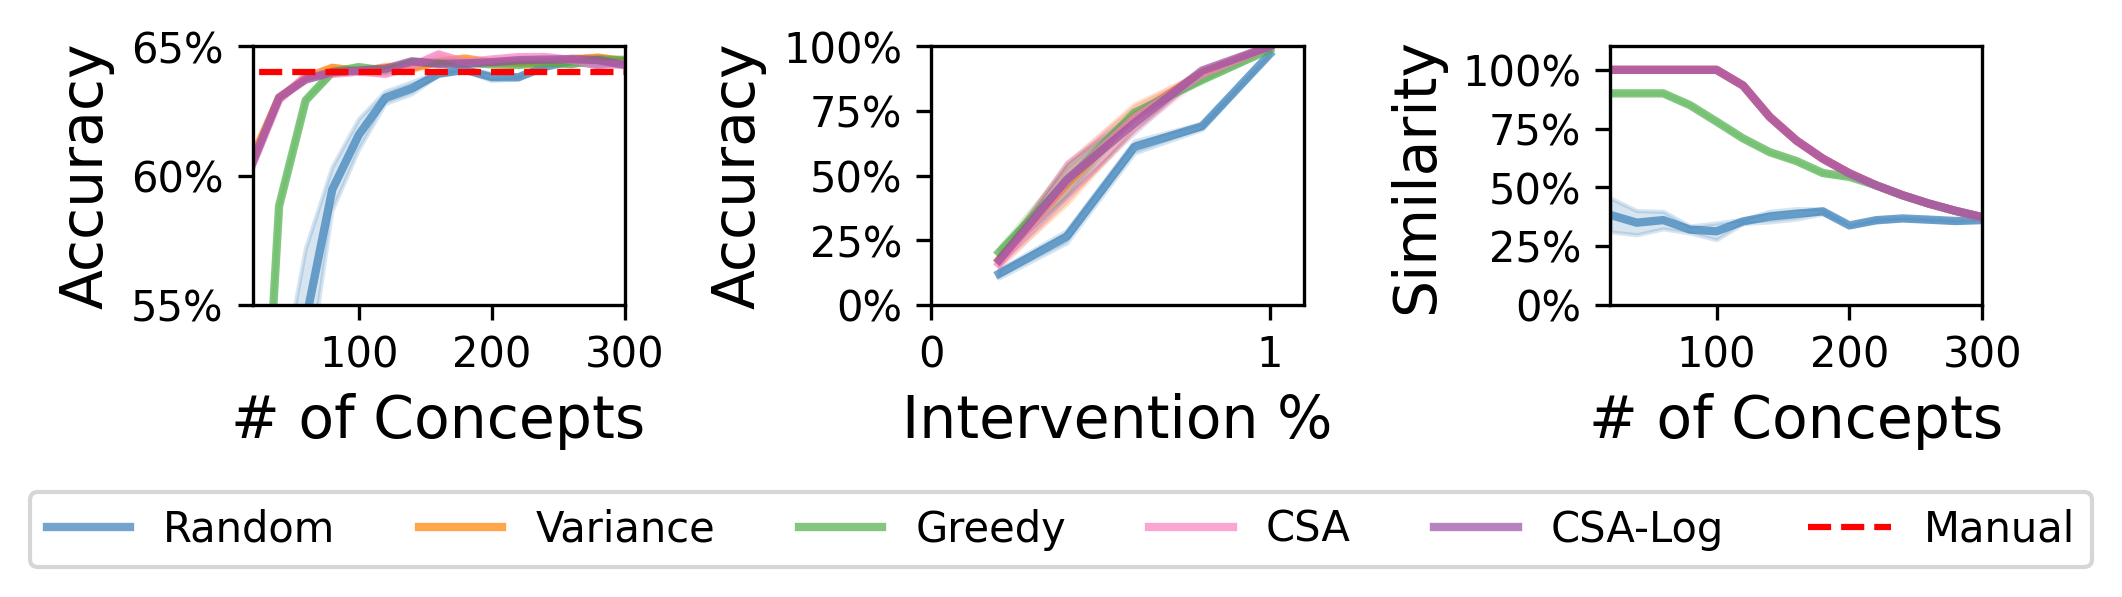

In [194]:
# -------------------------
# Figure setup
# -------------------------
plot_dimensions = (1, 3)
METHODS["manual"] = "Manual"

overall_format = {
    "figsize": (7, 2),
    "style_size": style_size,
    "has_grid": False,
    "x_lim": [[[20, 300], [0, 1.1], [20, 300]]],
    "y_lim": [[[0.55, 0.65], [0, 1], [0, 1.1]]],
    "y_ticks": [[
        [[0.55, 0.6, 0.65], ["55%", "60%", "65%"]],
        [[0, 0.25, 0.5, 0.75, 1], ["0%", "25%", "50%", "75%", "100%"]],
        [[0, 0.25, 0.5, 0.75, 1], ["0%", "25%", "50%", "75%", "100%"]],
    ]],
}

fig, ax = create_axes(
    plot_dimensions,
    overall_format,
    x_labels=[["# of Concepts", "Intervention %", "# of Concepts"]],
    y_labels=[["Accuracy", "Accuracy", "Similarity"]],
)

line_format = {"color_palette": "six_color", "linewidth": 2}

# -------------------------
# Panel 1: reward vs #concepts
# -------------------------
methods_panel1 = ["random", "entropy", "greedy", "lp", "multiple"]
labels_panel1 = [METHODS[m] for m in methods_panel1]

plot_line(
    ax[0][0],
    [C_VALUES] * len(methods_panel1),
    [rewards[m] for m in methods_panel1],
    [rewards_stderr[m] for m in methods_panel1],
    labels_panel1,
    line_format,
)

ax[0][0].hlines(
    manual_reward, 0, 311, label="Manual", color="red", linestyle="--"
)

# -------------------------
# Panel 2: intervention
# -------------------------
methods_panel2 = ["random", "entropy", "greedy", "lp", "multiple"]
labels_panel2 = [METHODS[m] for m in methods_panel2]

plot_line(
    ax[0][1],
    [INTERVENTIONS] * len(methods_panel2),
    [intervention_rewards[m] for m in methods_panel2],
    [intervention_stderr[m] for m in methods_panel2],
    labels_panel2,
    line_format,
)

# -------------------------
# Panel 3: similarity
# -------------------------
plot_line(
    ax[0][2],
    [C_VALUES] * len(methods_panel1),
    [similarities[m] for m in methods_panel1],
    [similarities_stderr[m] for m in methods_panel1],
    labels_panel1,
    line_format,
)

# -------------------------
# Legend + save
# -------------------------
legend_format = {
    "style_size": style_size,
    "type": "is_global",
    "loc": "lower left",
    "ncol": 6,
    "bbox_to_anchor": (0.02, -0.08),
    "fontsize": 10,
}

create_legend(fig, ax, plot_dimensions, legend_format)
plt.tight_layout()
fig.savefig(
    "../../results/figures/imperfect_cub.pdf",
    dpi=300,
    bbox_inches="tight",
)
